# Einsatzdaten der Berliner Feuerwehr

## Einleitung und Fragestellung

Wird die Einhaltung der Hilfsfrist bei Einsätzen der Berliner Feuerwehr durch
- die Art des Einsatzes,
- die Systemlast der Leitstelle
- dem Standort (nach Berliner Bezirken)
- oder externe Faktoren wie das Wetter beeinflusst?

Hierfür haben wir uns den Open-Data Datensatz der Berliner Feuerwehr sowie Wetterdaten analysiert.
Die Berliner Feuerwehr stellt seit fast zehn Jahren Daten aus Einsätzen öffentlich zur Verfügung und unterstützt damit die Open-Data Strategie Berlins.
Darunter sind zum Beispiel allgemeine Einsatzdaten, Dispatchcodes, Regionale Daten, Ausrückzeiten und auch Daten aus den Leitstellen und der täglichen Abgabe an die Kassenärztliche Vereinigung Berlins.

Vor allem in Hinblick auf die Einschnitte im Gesundheitssystem<sup>1</sup> (https://www.tagesschau.de/inland/innenpolitik/reform-gesundheitssystem-warken-100.html), die nicht ausreichende Digitalisierung im Gesundheitsbereich<sup>2</sup> (https://www.aok.de/pp/gg/update/schleppende-digitalisierung/) und dem Fachkräftemangel<sup>3</sup> () sind öffentliche Daten ein wichtiges Mittel um demokratische Prozesse zu unterstützen und der Gesellschaft eine Möglichkeit zu geben, Transparenz zu schaffen.
Dabei gibt es für die Hilfsfrist in Deutschland keinen gesetzlichen Standard, heißt die Empfehlung von acht Minuten Ausrückzeit für einen lebensbedrohlichen Einsatz ist in vielen Bereichen Deutschlands nicht einheitlich geregelt. 
So auch in Berlin. Hier gibt es keine gesetzlich bindende Hilfsfrist, sondern ein vereinbartes "Schutzziel". Die Berliner Feuerwehr selbst nennt 90% Erreichungsgrad in 10 bzw. 11 Minuten je nach Notfallart. 
Aufgrund der medizinischen Relevanz der 8-minütigen Hilfsfrist bei lebensbedrohlichen Einsätzen wurde für die Analyse diese Grenze gewählt. Diese Grenze begründet sich alleine aus der Tatsache, dass schon nach wenigen Minuten irreversible Hirnschäden bei Kreislauf-/Atemstillstand auftreten können, da die Sauerstoffversorgung unterbrochen ist. 
Diese Wahl deckt sich außerdem mit der Empfehlung einer Organisationsuntersuchung des Rettungsdienstes im Land Berlin von 2016: statt des damals geltenden, regional gestaffelten Schutzziels (8 Minuten, erreicht in 75% der Fälle im zentralen Berlin bzw. 50% in ländlichen Gebieten) empfiehlt die Studie ein einheitliches Ziel von mindestens 90% aller Notfälle innerhalb von 8 Minuten — und zwar für alle Einsätze, nicht nur die dringendsten<sup>4</sup> (siehe https://www.berliner-feuerwehr.de/fileadmin/bfw/dokumente/status-5/G668_Orga-RD_Berlin__Stand_22.07.16_.pdf).
Somit sind unsere Zahlen zwar strenger als Berlins eigenes, aktuelles Schutzziel (90% in 10 bzw. 11 Minuten), decken sich aber mit einer fachlich begründeten Empfehlung und unterstreichen zusätzlich das Problem in Rettungseinrichtungen.
Auf Empfehlung der Björn Steiger Stiftung sollen Hilfsfristen gestaffelt werden. Leider war bis zum heutigen Datum (18. Juni 2026) die Empfehlung der Björn Steiger Stiftung über die Hilfsfristen je nach Einsatzart noch nicht veröffentlicht<sup>5</sup> (siehe https://rettungslandschaft.steiger-stiftung.de/wann-kommt-steiger-hilfsfristmodell/).

Für die Wetterdaten haben wir die REST-API von Open Meteo genutzt.

### Hypothesen

1. Die Art des Einsatzes (z.B. kritischer Rettungsdienst vs. Brand) beeinflusst die Einhaltung der Hilfsfrist unterschiedlich stark — kritische Einsätze werden priorisiert und sollten häufiger eingehalten werden.
2. Eine hohe Systemlast der Leitstelle (viele unbeantwortete Anrufe, lange Antwortzeiten) korreliert mit einer schlechteren Hilfsfrist-Einhaltung.
3. Extreme Wetterlagen (Stürme, Starkregen, Hitze) erhöhen sowohl die Systemlast der Leitstelle als auch die Wahrscheinlichkeit, dass die Hilfsfrist verfehlt wird — Wetter wirkt also vermutlich indirekt über die Leitstelle.

Einschränkung: Leitstellen-/Anrufdaten sind erst ab 2024 verfügbar. Der gemeinsame Datensatz für die Modellierung ist deshalb auf 2024–2025 beschränkt, auch wenn Einsatz- und Wetterdaten weiter zurückreichen.

# Datenimport

- Laden der täglichen Einsatz- und Anrufdaten der Berliner Feuerwehr aus dem BF-Open-Data-Repository
- Laden der Wetterdaten über die REST-API von Open-Meteo (Vorlage für Code stammt von Open Meteo)
- Überführen aller Daten in geeignete Formate (z.B. Datumsspalten) für die spätere Analyse
- Start- und Enddatum für die Analyse manuell auf 2022–2025 festgelegt, um COVID-19 Ausreißer auszuschließen

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Start- und Enddatum
start_date = pd.Timestamp("2022-01-01")
end_date = pd.Timestamp("2025-12-31")

# daily_mission Daten
df_daily_mission = pd.read_csv("data/BF-Open-Data/Datasets/Daily_Data/BFw_mission_data_daily.csv")
# Geeignetes Datenformat wählen
df_daily_mission["mission_created_date"] = pd.to_datetime (df_daily_mission["mission_created_date"])
df_daily_mission = df_daily_mission.set_index("mission_created_date").sort_index()


# daily_call Daten
df_daily_call = pd.read_csv("data/BF-Open-Data/Datasets/Daily_Data/BFw_call_data_daily.csv")
# Geeignetes Datenformat wählen
df_daily_call["calls_received_day"] = pd.to_datetime(df_daily_call["calls_received_day"])
df_daily_call = df_daily_call.sort_values("calls_received_day").set_index("calls_received_day")
# call_count als str eingelesen → in int umwandeln
df_daily_call["call_count"] = pd.to_numeric(df_daily_call["call_count"], errors="coerce")

# mission_data Daten
df_mission_data = pd.concat([
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2022.csv", low_memory=False),
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2023.csv", low_memory=False),
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2024.csv", low_memory=False),
    pd.read_csv("data/BF-Open-Data/Datasets/Mission_Data/mission_data_set_open_data_2025.csv", low_memory=False),], ignore_index=True)

# Geeignetes Datenformat wählen
df_mission_data["mission_date"] = pd.to_datetime(df_mission_data["mission_date"])
df_mission_data = df_mission_data.set_index("mission_date").sort_index()

# Filter für die Daten
df_daily_mission = df_daily_mission.loc[start_date:end_date]
df_daily_call = df_daily_call.loc[start_date:end_date]
df_mission_data = df_mission_data.loc[start_date:end_date]

In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.52,
	"longitude": 13.41,
	"start_date": "2022-01-01",
	"end_date": "2025-12-31",
	"daily": ["temperature_2m_max", "weather_code", "precipitation_sum", "snowfall_sum", "wind_speed_10m_max"],
	"timezone": "Europe/Berlin",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_weather_code = daily.Variables(1).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(2).ValuesAsNumpy()
daily_snowfall_sum = daily.Variables(3).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(4).ValuesAsNumpy()

daily_data = {
	"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["weather_code"] = daily_weather_code
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["snowfall_sum"] = daily_snowfall_sum
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max

df_weather = pd.DataFrame(data = daily_data)
df_weather = df_weather.set_index("date")
df_weather.index = df_weather.index.tz_localize(None)
print("\nDaily data\n", df_weather)



Coordinates: 52.52000045776367°N 13.419998168945312°E
Elevation: 38.0 m asl
Timezone: b'Europe/Berlin'b'GMT+2'
Timezone difference to GMT+0: 7200s

Daily data
                      temperature_2m_max  weather_code  precipitation_sum  \
date                                                                       
2021-12-31 23:00:00             12.0500          51.0                0.6   
2022-01-01 23:00:00             11.6500          53.0                2.3   
2022-01-02 23:00:00             10.0500          55.0                2.9   
2022-01-03 23:00:00              7.2000          51.0                2.3   
2022-01-04 23:00:00              4.6000          51.0                0.7   
...                                 ...           ...                ...   
2025-12-26 23:00:00              3.6455          77.0                0.1   
2025-12-27 23:00:00              2.7455           3.0                0.0   
2025-12-28 23:00:00              4.4955          77.0                0.5   
2025

# Datenverständnis

Bevor mit der Bereinigung und Analyse begonnen wird, verschaffen wir uns einen Überblick über die geladenen Datensätze: wie viele Einsätze/Tage liegen vor, welche Spalten und Datentypen gibt es, und wo gibt es fehlende Werte (NaN)? Das bildet die Grundlage für die Entscheidungen in der folgenden Datenbereinigung.

In [3]:
# mission data
print(df_mission_data.shape)
print(df_daily_mission.dtypes)
df_mission_data.head()

#missing values
df_mission_data.isnull().sum()

#zielvariable prüfen
print(df_mission_data["response_time"].describe())
print((df_mission_data["response_time"] <= 480).mean())

(2129064, 16)
mission_count_all                                   int64
mission_count_ems                                   int64
mission_count_ems_critical                          int64
mission_count_ems_critical_cpr                      int64
mission_count_fire                                  int64
mission_count_technical_rescue                      int64
mission_count_rd1                                   int64
mission_count_rd2                                   int64
mission_count_rd3                                   int64
mission_count_rd4                                   int64
mission_count_rd5                                   int64
response_time_ems_critical_mean                   float64
response_time_ems_critical_median                 float64
response_time_ems_critical_std                    float64
response_time_ems_critical_cpr_mean               float64
response_time_ems_critical_cpr_median             float64
response_time_ems_critical_cpr_std                float64


Über 2 Millionen Einsätze, 16 Variabeln

8-Minuten-Schutzziel (480 Sekunden) — keine gesetzliche Hilfsfrist, sondern ein politisch vereinbartes Schutzziel mit 75%-Zielquote (siehe Korrektur oben):
Mean: 677 Sekunden (ca 11 Minuten)
Median: 625 Sekunden (ca 10 Minuten)
Min: 121 Sekunden
Max: 1919 Sekunden (ca 32 Minuten)
Count: ca 264.000 Einträge haben keinen Wert (NaN) --> ca 12% muss bereinigt werden
17,2% der Einsätze halten das 8-Minuten-Schutzziel ein


In [4]:
#daily mission data
print(df_daily_mission.shape)
print(df_daily_mission.dtypes)
df_daily_mission.head()

#missing values
df_daily_mission.isnull().sum()

#zielvariable prüfen
print(df_daily_mission["response_time_ems_critical_mean"].describe())
print(df_daily_mission["response_time_ems_critical_cpr_mean"].describe())

(1461, 29)
mission_count_all                                   int64
mission_count_ems                                   int64
mission_count_ems_critical                          int64
mission_count_ems_critical_cpr                      int64
mission_count_fire                                  int64
mission_count_technical_rescue                      int64
mission_count_rd1                                   int64
mission_count_rd2                                   int64
mission_count_rd3                                   int64
mission_count_rd4                                   int64
mission_count_rd5                                   int64
response_time_ems_critical_mean                   float64
response_time_ems_critical_median                 float64
response_time_ems_critical_std                    float64
response_time_ems_critical_cpr_mean               float64
response_time_ems_critical_cpr_median             float64
response_time_ems_critical_cpr_std                float64
res

Critical EMS:
- Mean: 642 Sekunden (ca. 10.7 Minuten)
- Min: 558 Sekunden (ca. 9.3 Minuten) !!!

Critical EMS CPR:
- Mean: 505 Sekunden (ca. 8.4 Minuten)
- Min: 360 Sekunden (6 Minuten)

CPR Einsätze werden schneller beantwortet als allgemein kritische Fälle. Annahme: Priorisierungssystem der Leistelle funktioniert. CPR hat höchste prio.

In [5]:
#daily calls
print(df_daily_call.shape)
print(df_daily_call.dtypes)
df_daily_call.head()

#missing values
df_daily_call.isnull().sum()

#zielvariable prüfen
print(df_daily_call["answer_time_mean_112"].describe())
print(df_daily_call["call_count_112"].describe())
print(df_daily_call["call_count_112_not_answered"].describe())
print(df_daily_call["call_count_112_answered_after_60_seconds"].describe())
print(df_daily_call["call_count_112_answered_within_10_seconds"].describe())

#Für die Systemauslastung
#Anteil nicht beantworteter Anrufe
#call_count_112 zählt laut Datenbeschreibung nur beantwortete Anrufe → korrekter Nenner: call_count_112 + call_count_112_not_answered
print("not answered rate")
df_daily_call["not_answered_rate"] = df_daily_call["call_count_112_not_answered"] / (df_daily_call["call_count_112"] + df_daily_call["call_count_112_not_answered"])
print(df_daily_call["not_answered_rate"].describe())

#Anteil nach 60 Sekunden beantwortet
print("after 60 rate")
df_daily_call["after_60s_rate"] = df_daily_call["call_count_112_answered_after_60_seconds"] / df_daily_call["call_count_112"]
print(df_daily_call["after_60s_rate"].describe())

(731, 12)
call_count                                   float64
answer_time_mean                             float64
answer_time_median                           float64
answer_time_std                              float64
call_count_not_answered                        int64
call_count_112                                 int64
answer_time_mean_112                         float64
answer_time_median_112                       float64
answer_time_std_112                          float64
call_count_112_not_answered                    int64
call_count_112_answered_within_10_seconds      int64
call_count_112_answered_after_60_seconds       int64
dtype: object
count    731.000000
mean      26.121094
std       10.197669
min        9.160000
25%       18.245000
50%       24.410000
75%       31.940000
max       68.590000
Name: answer_time_mean_112, dtype: float64
count     731.000000
mean     2315.545828
std       215.568643
min      1366.000000
25%      2181.500000
50%      2288.000000
75%      24

In [6]:
from scipy import stats

#Ausreißer mit Z score herausfinden (claude gefragt)
z_score = stats.zscore(df_daily_call["not_answered_rate"])
ausreisser = df_daily_call[abs(z_score) > 3]
print(ausreisser.sort_values("not_answered_rate", ascending = False))

                    call_count  answer_time_mean  answer_time_median  \
calls_received_day                                                     
2025-01-01              3226.0             39.46                9.81   
2025-06-23              3741.0             49.65               15.44   
2025-06-26              2757.0             40.66                7.52   

                    answer_time_std  call_count_not_answered  call_count_112  \
calls_received_day                                                             
2025-01-01                    72.43                     3709            3015   
2025-06-23                    82.28                     2954            3464   
2025-06-26                   100.85                     2000            2551   

                    answer_time_mean_112  answer_time_median_112  \
calls_received_day                                                 
2025-01-01                         40.67                   10.04   
2025-06-23                        

Die Z-Score-Ausreißer (`|z|>3`) bei `not_answered_rate` und `after_60s_rate` lassen sich größtenteils erklären:

- **01.01.2025**: laut README-Disclaimer der Berliner Feuerwehr gab es zum Jahreswechsel 24/25 eine technische Einschränkung der 112-Rufnummer, Notrufe liefen über ein Fallback-System ohne automatisierte Erfassung. Die Zahlen für diesen Tag sind unvollständig → **wird aus der Analyse entfernt**, da es sich um einen Datenfehler statt um eine echte Lastspitze handelt.
- **23.06. und 26.06.2025**: an beiden Tagen gab es laut Open-Meteo-Daten schwere Gewitter mit Windböen von 85–88 km/h (weather_code 95/96) nach einer Hitzewelle. Das erklärt den Anstieg unbeantworteter Notrufe plausibel und **belegbar** → bleibt in den Daten, dient sogar als Beispiel für den vermuteten Wetter→Leitstelle-Zusammenhang.
- **07.09. und 20.11.2024**: keine Wetterauffälligkeiten an diesen Tagen. Mögliche Erklärung: Großveranstaltungen (07.09. Start von Lollapalooza Berlin, 20.11. diverse Konzerte) könnten zu mehr Notrufen geführt haben — diese Erklärung ist aber **nicht belegt**, da in einer Stadt mit 3,8 Mio. Einwohnern an fast jedem Tag irgendwelche Veranstaltungen stattfinden. Die Tage bleiben in den Daten, werden aber als ungeklärt dokumentiert statt kausal erklärt.

FEHLER MEINERSEITS (aus dem vorherigen Durchgang): die `call_count`-Spalten zählen nur die *beantworteten* Anrufe, nicht alle eingegangenen — das hat die ursprüngliche Berechnung der Rate verzerrt, ist hier aber bereits korrigiert (Nenner = `call_count_112 + call_count_112_not_answered`).

Antwortzeit wird von der Björn Steigerstiftung für kritische fälle
answer_time_mean_112:
- Mean: 26 Sekunden
- Max: 68 Sekunden

not_answered_rate:
mean 34,6%
Max 121% (?)

after_60s_rate:
- mean 13,2%
- max 40,4%


In [7]:
#Wetterdaten
print(df_weather.shape)
print(df_weather.dtypes)
df_weather.head()

#missing values
print(df_weather.isnull().sum())

#zielvariable prüfen
print(df_weather.describe())

(1461, 5)
temperature_2m_max    float32
weather_code          float32
precipitation_sum     float32
snowfall_sum          float32
wind_speed_10m_max    float32
dtype: object
temperature_2m_max    0
weather_code          0
precipitation_sum     0
snowfall_sum          0
wind_speed_10m_max    0
dtype: int64
       temperature_2m_max  weather_code  precipitation_sum  snowfall_sum  \
count         1461.000000   1461.000000        1461.000000   1461.000000   
mean            15.343751     41.247089           1.569404      0.034209   
std              8.650467     34.070755           3.347269      0.268591   
min             -4.954500      0.000000           0.000000      0.000000   
25%              8.345500      3.000000           0.000000      0.000000   
50%             15.345500     51.000000           0.100000      0.000000   
75%             22.345499     77.000000           1.500000      0.000000   
max             37.650002     99.000000          40.099995      6.369999   

       w

# Datenbereinigung

**Zeitraum:** Mission- und Wetterdaten reichen weiter zurück (2018 bzw. 2022), aber `df_daily_call` existiert erst seit 2024. Da die Leitstellen-Auslastung zentral für unsere Fragestellung ist, beschränken wir den gemeinsamen Datensatz für die Modellierung auf 2024–2025. Explorative Auswertungen, die nur Mission- oder Wetterdaten brauchen, können trotzdem den längeren Zeitraum nutzen.

**Wetterdaten-Bug:** Durch die UTC→Europe/Berlin-Konvertierung landet der Zeitindex von `df_weather` auf 23:00 Uhr des Vortags statt auf Mitternacht. Vor dem Join wird der Index korrigiert, sonst würden Wetterdaten dem falschen Tag zugeordnet werden.

**response_time NaN:** ca. 12% der Einsätze (≈265.000 von 1,86 Mio.) haben keinen Wert bei `response_time`. Diese Zeilen werden entfernt, da sich für sie keine Zielvariable berechnen lässt.

**response_time Ausreißer werden NICHT entfernt:** Ein Z-Score-Test zeigt ca. 36.000 Einsätze (~2%) mit ungewöhnlich langer Reaktionszeit (1455–1919 Sekunden). Bei genauer Betrachtung sammeln sich die Außreißer vor allem bei nicht lebensbedrohlichen Einsätzen an. Sie zu entfernen würde die Zielvariable künstlich verzerren.

**dispatchcode_criticality / dispatchcode_category NaN:** ca. 111.000 Einsätze haben keinen Dispatchcode. Statt diese Zeilen zu droppen was einen hohen Datenverlust bedeuten würde, wird eine eigene Kategorie "unbekannt" eingeführt.

**Zielvariable:** `hilfsfrist = response_time <= 480` (480 Sekunden = Hilfsfrist, **keine gesetzliche Hilfsfrist von Berlin**)

**Zeitliche Features:** aus `mission_date` werden Wochentag und Monat extrahiert. Eine Uhrzeit-Variable ("Stunde") ist nicht möglich, da `mission_date` in allen Jahresdateien (2018–2026) ausschließlich das Datum ohne Uhrzeitkomponente enthält — keiner der verfügbaren BF-Open-Data-Datensätze (Mission_Data, Daily_Data, Turnout_Times, KV_Data, Regional_Data) liefert eine Uhrzeit-Auflösung. Die Granularität der Daten kann die Analyse einschränken.


In [8]:
# Wetter anpassen, Zeitstempel-Bug korrigieren
df_weather.index = (df_weather.index + pd.Timedelta(hours=1)).normalize()

# Kontrolle
print(df_weather.index.min(), df_weather.index.max())
print(df_weather.head())
print(df_weather.tail())

2022-01-01 00:00:00 2025-12-31 00:00:00
            temperature_2m_max  weather_code  precipitation_sum  snowfall_sum  \
date                                                                            
2022-01-01               12.05          51.0                0.6           0.0   
2022-01-02               11.65          53.0                2.3           0.0   
2022-01-03               10.05          55.0                2.9           0.0   
2022-01-04                7.20          51.0                2.3           0.0   
2022-01-05                4.60          51.0                0.7           0.0   

            wind_speed_10m_max  
date                            
2022-01-01           23.444265  
2022-01-02           29.168886  
2022-01-03           36.447220  
2022-01-04           16.243940  
2022-01-05           29.478260  
            temperature_2m_max  weather_code  precipitation_sum  snowfall_sum  \
date                                                                            

In [9]:
# response_time NaN entfernen
print("vorher:", df_mission_data.shape)
# dropna löscht Zeilen wo NaN ist
df_mission_data = df_mission_data.dropna(subset=["response_time"])
print("nachher", df_mission_data.shape)

vorher: (2129064, 16)
nachher (1864875, 16)


In [10]:
# Zielvariable Hilfsfrist eingehalten
df_mission_data["hilfsfrist"] = df_mission_data["response_time"] <= 480
print(df_mission_data["hilfsfrist"].value_counts(normalize=True))

# Wochentag und Monat aus dem Datums-Index rausziehen
df_mission_data["wochentag"] = df_mission_data.index.day_name()
df_mission_data["monat"] = df_mission_data.index.month

print(df_mission_data[["wochentag", "monat"]].head())

hilfsfrist
False    0.80334
True     0.19666
Name: proportion, dtype: float64
             wochentag  monat
mission_date                 
2022-01-01    Saturday      1
2022-01-01    Saturday      1
2022-01-01    Saturday      1
2022-01-01    Saturday      1
2022-01-01    Saturday      1


### Kategoriale Variablen encodieren

Modelle rechnen nur mit Zahlen, nicht mit Text wie `"Brand"` oder `"Mitte"`.

- **NaN bei `dispatchcode_criticality`** → wird zu eigener Kategorie `"unbekannt"` (statt Zeilen zu löschen).
- **One-Hot-Encoding** für `mission_type`, `mission_location_district`, `dispatchcode_criticality`: jede Kategorie wird eine eigene 0/1-Spalte. So entsteht keine künstliche Rangordnung zwischen den Kategorien (z.B. Bezirken), wie es bei einer einfachen Durchnummerierung der Fall wäre.
- Ergebnis: mehr Spalten, gleich viele Zeilen.

In [11]:
# NaN bei Dispatchcode als eigene Kategorie "unbekannt"
df_mission_data["dispatchcode_criticality"] = df_mission_data["dispatchcode_criticality"].fillna("unbekannt")

# One-Hot-Encoding (für Modelltraining wichtig)
df_mission_data = pd.get_dummies(
    df_mission_data,
    columns=["mission_type", "mission_location_district", "dispatchcode_criticality"],
    prefix=["typ", "district", "criticality"],
)

print(df_mission_data.shape)
df_mission_data.head()

# Nach Rettungsdienst-Einsätze + Rettungseinsätze mit technischer Hilfsleistung filtern für Hilfsfrist 
print("vorher: ", df_mission_data.shape)
df_mission_data = df_mission_data[
    (df_mission_data["typ_Rettungsdienst"] == True) |
    (df_mission_data["typ_Rettungsdienst mit Technischer Hilfeleistung"] == True)
]
print("nachher:", df_mission_data.shape)

(1864875, 41)
vorher:  (1864875, 41)
nachher: (1714419, 41)


In [12]:
# Silvester-Tag entfernen: dokumentierter Systemausfall (README-Disclaimer)
print("vorher:", df_daily_call.shape)
df_daily_call = df_daily_call.drop(pd.Timestamp("2025-01-01"))
print("nachher:", df_daily_call.shape)

vorher: (731, 14)
nachher: (730, 14)


# Explorative Analyse: Vorgehen

Wir schauen uns die Daten in vier Stufen an, statt direkt mit komplexen Visualisierungen zu starten:

1. **Langer Zeitraum (2022–2025), einzeln:** Einsatztyp, Wetter, Wochentag, Monat — je für sich gegen `hilfsfrist`. Soll zeigen welche Variabeln einen Effekt haben.
2. **Langer Zeitraum, kombiniert:** Nur für Variablen, die in Stufe 1 einzeln schon ein Muster zeigen.
3. **Kurzer Zeitraum (2024–2025), einzeln:** Leitstellen-Variablen (`not_answered_rate`, `answer_time_mean_112`, ...) gegen `hilfsfrist`/`response_time`. Geht nicht über den langen Zeitraum, da Leitstellendaten erst ab 2024 existieren.
4. **Kurzer Zeitraum, kombiniert:** Leitstelle zusammen mit Wetter bzw. Einsatztyp

## Hilfsfrist VS Dringlichkeitsstufe

**Befund:** Es ist sichtbar, dass es eine Korrelation zwischen der Einhaltung der Hilfsfrist und den Dringlichkeitsstufen (AMPDS) vorhanden ist.

O            0.096576
A            0.151716
B            0.176774
C            0.184365
D            0.264220
E            0.448182
unbekannt    0.336278
dtype: float64


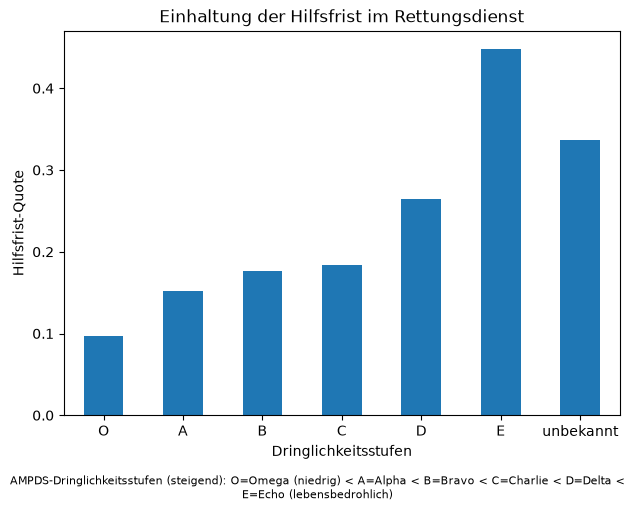

In [13]:
# Hilfsfrist-Quote nach Dringlichkeitsstufe
crit_spalten = [col for col in df_mission_data.columns if col.startswith("criticality_")]
quote_je_crit = {
    col.replace("criticality_", ""): df_mission_data.loc[df_mission_data[col], "hilfsfrist"].mean()
    for col in crit_spalten
}
quote_je_crit = pd.Series(quote_je_crit)

# Nach AMPDS-Dringlichkeit sortieren (O < A < B < C < D < E), statt nach Quote
reihenfolge = ["O", "A", "B", "C", "D", "E", "unbekannt"]
quote_je_crit = quote_je_crit.reindex([k for k in reihenfolge if k in quote_je_crit.index])

print(quote_je_crit)

quote_je_crit.plot(kind="bar")
plt.ylabel("Hilfsfrist-Quote")
plt.xlabel("Dringlichkeitsstufen")
plt.title("Einhaltung der Hilfsfrist im Rettungsdienst")
plt.xticks(rotation=0)

# Diagramm Beschriftung
plt.figtext(
    0.5, -0.05,
    "AMPDS-Dringlichkeitsstufen (steigend): O=Omega (niedrig) < A=Alpha < B=Bravo < C=Charlie < D=Delta < E=Echo (lebensbedrohlich)",
    wrap=True, ha="center", fontsize=8
)

plt.tight_layout()
plt.show()

## Wetter vs. Hilfsfrist (Stufe 1, einzeln)

Einsatzdaten (nur Rettungsdienst, langer Zeitraum 2022–2025) wurden auf das Tagesdatum mit den Wetterdaten gejoint. Es wurde nach `hilfsfrist` (eingehalten/nicht eingehalten) verglichen.

**Befund:** Die Verteilungen von Temperatur, Niederschlag und Windgeschwindigkeit sind für beide Gruppen (Hilfsfrist eingehalten vs. nicht eingehalten) nahezu identisch.

**Einordnung:** Das bedeutet nicht, dass Wetter keine Rolle spielt, keinen klaren direkten Zusammenhang mit der Hilfsfrist zeigt.

(1714419, 46)
temperature_2m_max    0
precipitation_sum     0
wind_speed_10m_max    0
dtype: int64


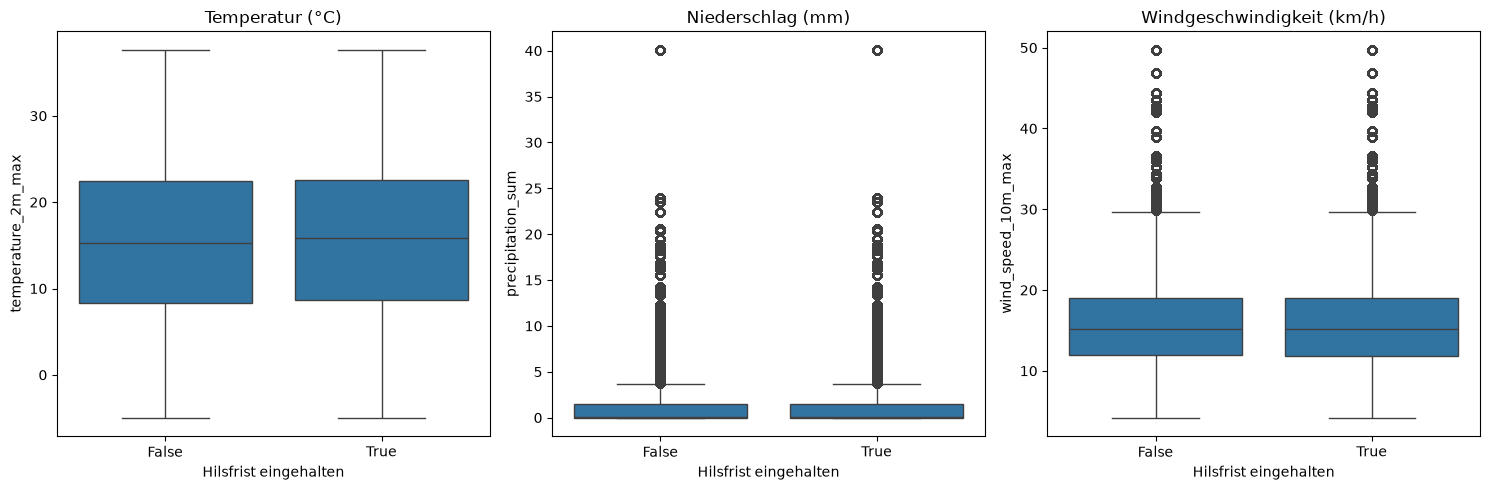

In [14]:
import seaborn as sns
# Einsatzdaten mit Wetter joinen
df_weather_mission = df_mission_data.join(df_weather, how="left")

print(df_weather_mission.shape)
print(df_weather_mission[["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max"]].isnull().sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variabeln = ["temperature_2m_max", "precipitation_sum", "wind_speed_10m_max"]
titel = ["Temperatur (°C)", "Niederschlag (mm)", "Windgeschwindigkeit (km/h)"]

for ax, var, t in zip(axes, variabeln, titel):
    sns.boxplot(data=df_weather_mission, x="hilfsfrist", y=var, ax=ax)
    ax.set_title(t)
    ax.set_xlabel("Hilsfrist eingehalten")

plt.tight_layout()
plt.show()

## Wochentag & Monat VS. Hilfsfrist

**Befund Monat (einzeln):** Die Hilfsfrist-Quote schwankt nur minimal über die Monate heißt es gibt kein erkennbares saisonales Muster. 

**Befund Wochentag (einzeln):** Am Wochenende wird die Hilfsfrist etwas häufiger eingehalten als werktags.

**Befund Heatmap Wochentag × Monat (kombiniert):** Nur geringe Abweichungen zwischen den Zellen, kein zusätzlicher Effekt.

**Einordnung**: Auch gibt es keine klar erkennbare Korrelation zwischen Sasion bzw. Wochentag und Hilfsfrist. Bis auf eine bessere Einhaltung an den Wochenenden, was vielleicht auch auf eine vorrausschauende PLanung zu schließen ist, hat sich nichts markant herausgestellt.

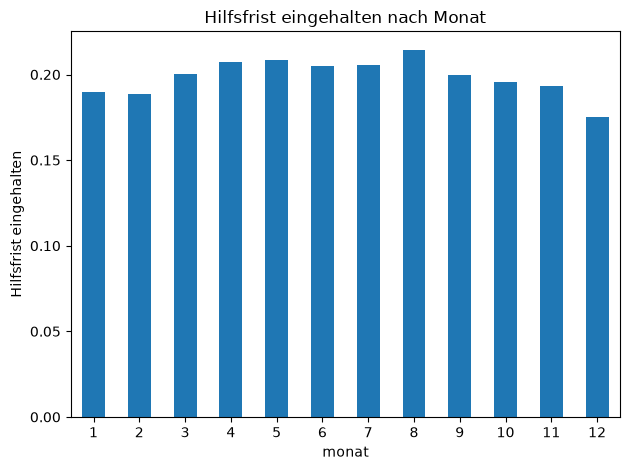

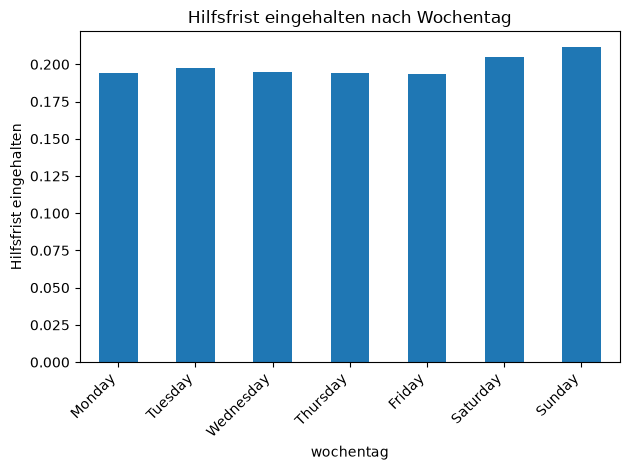

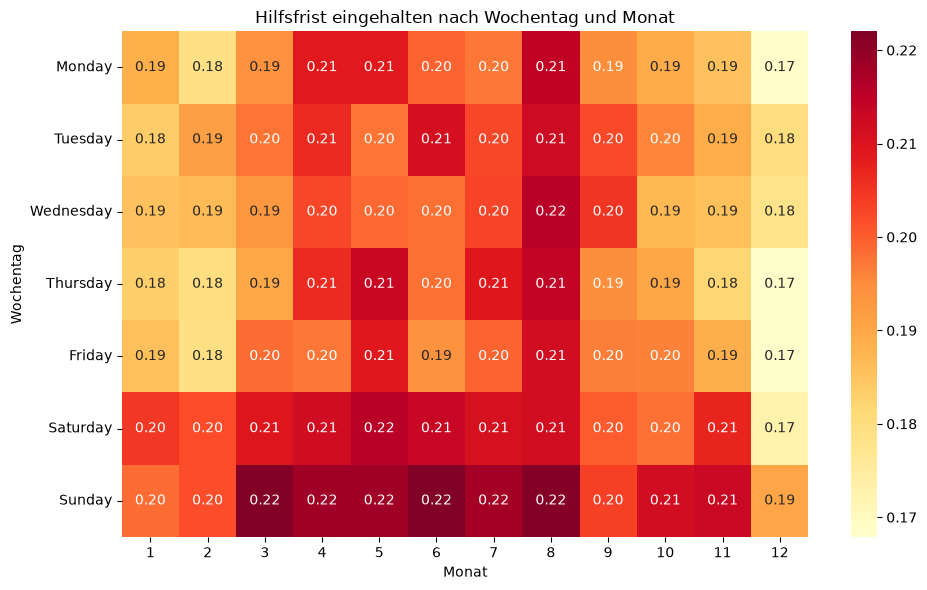

In [15]:
# Hilfsfrist-Quote pro Monat
quote_monat = df_mission_data.groupby("monat")["hilfsfrist"].mean()

quote_monat.plot(kind="bar")
plt.ylabel("Hilfsfrist eingehalten")
plt.title("Hilfsfrist eingehalten nach Monat")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Hilfsfrist-Quote je Wochentag
quote_wochentag = df_mission_data.groupby("wochentag")["hilfsfrist"].mean()
sort_wochentag = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
quote_wochentag = quote_wochentag.reindex(sort_wochentag)

quote_wochentag.plot(kind="bar")
plt.ylabel("Hilfsfrist eingehalten")
plt.title("Hilfsfrist eingehalten nach Wochentag")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Heatmap Hilfsfrist nach Wochentag, Monat
pivot = df_mission_data.pivot_table(index="wochentag", columns="monat", values="hilfsfrist", aggfunc="mean")

sort_wochentag = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = pivot.reindex(sort_wochentag)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Hilfsfrist eingehalten nach Wochentag und Monat")
plt.xlabel("Monat")
plt.ylabel("Wochentag")
plt.tight_layout()
plt.show()

## Hilfsfrist VS Bezirk

**Befund:**

Friedrichshain-Kreuzberg      0.305356
Mitte                         0.259641
Charlottenburg-Wilmersdorf    0.241904
Tempelhof-Schöneberg          0.222131
Spandau                       0.195812
Neukölln                      0.193774
Reinickendorf                 0.169152
Steglitz-Zehlendorf           0.166250
Pankow                        0.164474
Lichtenberg                   0.150768
Marzahn-Hellersdorf           0.129940
Treptow-Köpenick              0.126301
dtype: float64

Spannweite (max-min): 0.17905480783060332


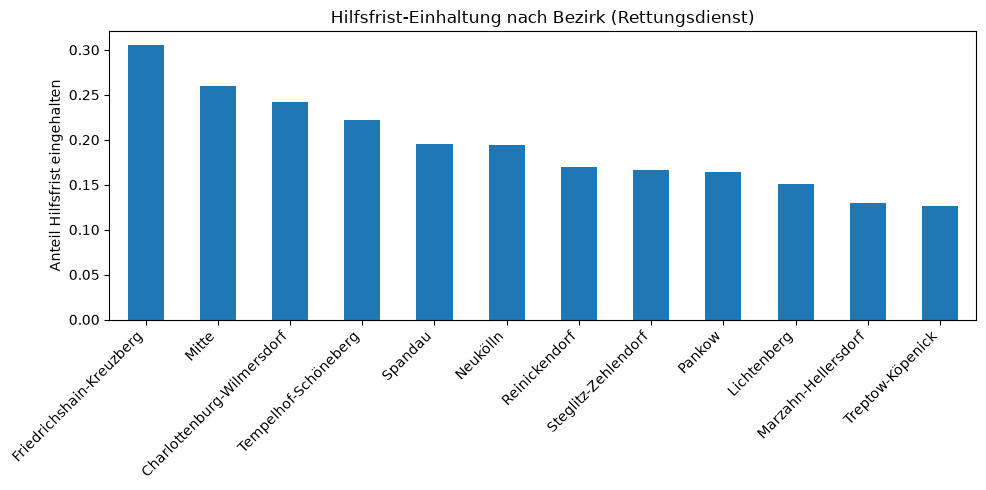

In [16]:
# Hilfsfrist-Quote nach Berliner Bezirk
district_spalten = [col for col in df_mission_data.columns if col.startswith("district_")]
quote_je_bezirk = {
    col.replace("district_", ""): df_mission_data.loc[df_mission_data[col], "hilfsfrist"].mean()
    for col in district_spalten
}
quote_je_bezirk = pd.Series(quote_je_bezirk).sort_values(ascending=False)

print(quote_je_bezirk)
print()
print("Spannweite (max-min):", quote_je_bezirk.max() - quote_je_bezirk.min())

plt.figure(figsize=(10, 5))
quote_je_bezirk.plot(kind="bar")
plt.ylabel("Anteil Hilfsfrist eingehalten")
plt.title("Hilfsfrist-Einhaltung nach Bezirk (Rettungsdienst)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

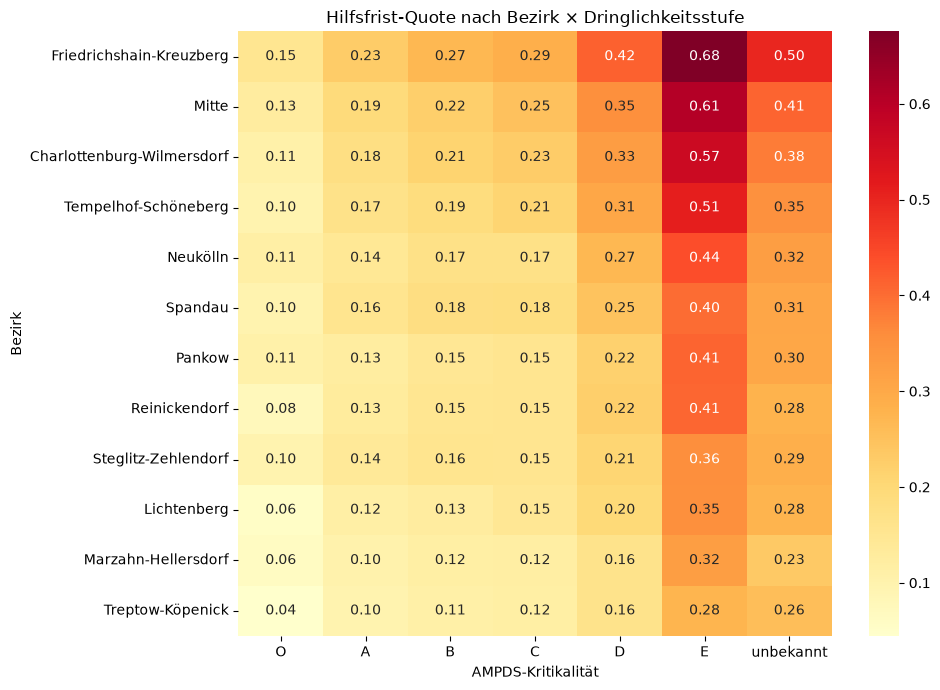

In [17]:
# Heatmap: Hilfsfrist-Quote nach Bezirk x Dringlichkeitsstufe
crit_spalten = [col for col in df_mission_data.columns if col.startswith("criticality_")]
district_spalten = [col for col in df_mission_data.columns if col.startswith("district_")]

pivot_daten = []
for d_col in district_spalten:
    bezirk = d_col.replace("district_", "")
    zeile = {}
    for c_col in crit_spalten:
        crit = c_col.replace("criticality_", "")
        maske = df_mission_data[d_col] & df_mission_data[c_col]
        zeile[crit] = df_mission_data.loc[maske, "hilfsfrist"].mean()
    pivot_daten.append(pd.Series(zeile, name=bezirk))

pivot_bezirk_crit = pd.DataFrame(pivot_daten)

# Spalten nach AMPDS-Dringlichkeit sortieren
reihenfolge = ["O", "A", "B", "C", "D", "E", "unbekannt"]
pivot_bezirk_crit = pivot_bezirk_crit[[c for c in reihenfolge if c in pivot_bezirk_crit.columns]]
# Nach Gesamtquote sortieren
pivot_bezirk_crit = pivot_bezirk_crit.loc[pivot_bezirk_crit.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_bezirk_crit, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Hilfsfrist-Quote nach Bezirk × Dringlichkeitsstufe")
plt.xlabel("AMPDS-Kritikalität")
plt.ylabel("Bezirk")
plt.tight_layout()
plt.show()

## Leistelle VS Hilfsfrist
**Befund:** Es ist kein klarer Zusammenhang zwischen der Beantwortung der Anrufe durch die Leitstelle und Hilfsfrist auszumachen

(888430, 55)
not_answered_rate       1458
after_60s_rate          1458
answer_time_mean_112    1458
dtype: int64


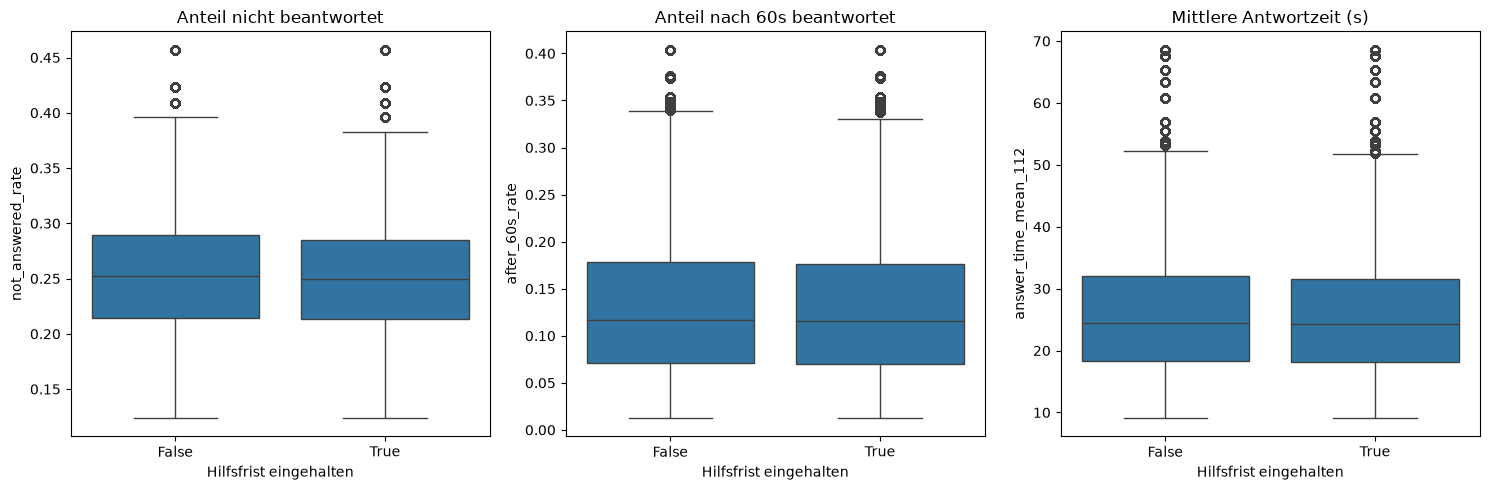

In [19]:
# Einsatzdaten auf Erfassung der Anrufe begrenzen (Jahre) 2024-2025
df_mission_data_cut = df_mission_data.loc[pd.Timestamp("2024-01-01"):pd.Timestamp("2025-12-31")]

# Einsatzdaten joinen mit Anrufdaten
df_leitstelle = df_mission_data_cut.join(df_daily_call, how="left")

print(df_leitstelle.shape)
print(df_leitstelle[["not_answered_rate", "after_60s_rate", "answer_time_mean_112"]].isnull().sum())

# Boxplot: Leistelle VS Hilfsfrist
df_leitstelle_plot = df_leitstelle.reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

leitstellen_var = ["not_answered_rate", "after_60s_rate", "answer_time_mean_112"]
titel = ["Anteil nicht beantwortet", "Anteil nach 60s beantwortet", "Mittlere Antwortzeit (s)"]

for ax, var, t in zip(axes, leitstellen_var, titel):
    sns.boxplot(data=df_leitstelle_plot, x="hilfsfrist", y=var, ax=ax)
    ax.set_title(t)
    ax.set_xlabel("Hilfsfrist eingehalten")

plt.tight_layout()
plt.show()



hilfsfrist_quote        1.000000
not_answered_rate      -0.294160
after_60s_rate         -0.175269
answer_time_mean_112   -0.181530
Name: hilfsfrist_quote, dtype: float64


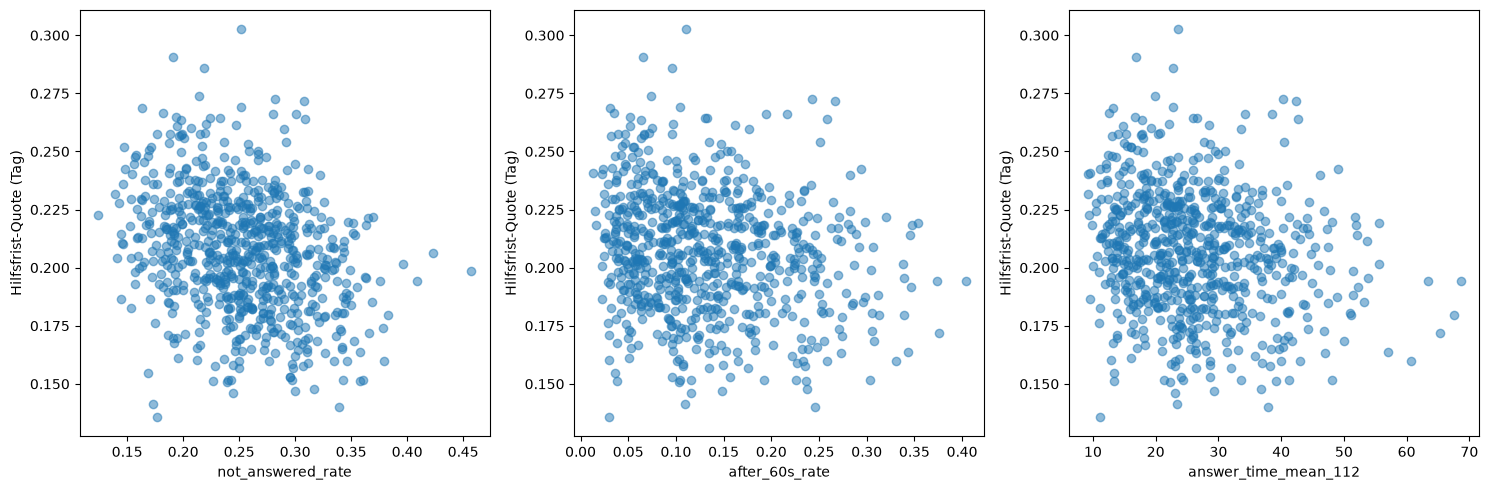

In [20]:
# Auf Tagesebene aggregieren statt pro Einsatz (vermeidet Verdünnung durch Einsatzebene-Varianz)
df_tage = df_leitstelle.groupby(df_leitstelle.index)["hilfsfrist"].mean().to_frame("hilfsfrist_quote")
df_tage = df_tage.join(df_daily_call[["not_answered_rate", "after_60s_rate", "answer_time_mean_112"]])

print(df_tage.corr()["hilfsfrist_quote"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, var in zip(axes, ["not_answered_rate", "after_60s_rate", "answer_time_mean_112"]):
    ax.scatter(df_tage[var], df_tage["hilfsfrist_quote"], alpha=0.5)
    ax.set_xlabel(var)
    ax.set_ylabel("Hilfsfrist-Quote (Tag)")
plt.tight_layout()
plt.show()

In [21]:
# Einsatzaufkommen pro Tag (Anzahl Rettungsdienst-Einsätze) als direkterer Systemlast-Indikator
df_tage["einsatz_anzahl"] = df_leitstelle.groupby(df_leitstelle.index).size()

print(df_tage.corr()["hilfsfrist_quote"])

# Zusätzlich: hängt not_answered_rate selbst mit dem Einsatzaufkommen zusammen?
print()
print("Korrelation not_answered_rate <-> Einsatzanzahl:", df_tage["not_answered_rate"].corr(df_tage["einsatz_anzahl"]))

hilfsfrist_quote        1.000000
not_answered_rate      -0.294160
after_60s_rate         -0.175269
answer_time_mean_112   -0.181530
einsatz_anzahl         -0.236096
Name: hilfsfrist_quote, dtype: float64

Korrelation not_answered_rate <-> Einsatzanzahl: 0.07171314386682752


## Leitstelle wird nicht weiterverfolgt

**Befund:** `not_answered_rate` korreliert statistisch signifikant mit der täglichen Hilfsfrist-Quote (r=-0,29, p≈0,000000, n=730 Tage). Der Zusammenhang ist aber moderat und somit deutlich schwächer als die Dringlichkeitsstufe oder der Bezirk.

**Einschränkung:** Die Feldbeschreibung definiert `call_count_112_not_answered` nur als "Number of emergency calls (112) not answered", ohne zu erklären, ob zum Beispiel Mehrfachanrufe zum selben Vorfall mitgezählt werden. Damit ist unklar, ob wirklich eine Systemüberlastung der Leitstelle gemessen oder das Anrufverhalten widerspiegelt wird. Die erklärbaren Ausreißertage (Silvester-Systemausfall, Sturmtage) sprechen für eine Aussagekraft, die unerklärten Außreißertage bleiben aber unbelegt.

**Entscheidung:** Aufgrund dieser Unsicherheit verfolgen wir die Leitstellen-Variablen für das Modelltraining nicht weiter. Wir können nicht sauber genug einordnen, was genau gemessen wird.

## Wie weit wird die Hilfsfrist bei Echo-Einsätzen - also Einsätzen mit der höchsten Dringlichkeitsstufe - über/unterschritten?

Es ist anzunehmen, dass die Leistelle die Einsätze genau genug priorisiert, sodass bei Einsätzen bei denen schnell gehandelt werden muss, die Hilfsfrist eingehalten wird.

**Befund:** Bei über 50% der Echo-Einsätze (lebensbedrohliche Situation) wird die Hilfsfrist verfehlt. Auch wenn eine geringe Überschreitung von zwei Minuten vorliegt, iat die Verzögerung medizinisch relevant.

count    15458.000000
mean       509.808061
std        136.480963
min        150.000000
25%        420.000000
50%        497.000000
75%        584.000000
max       1690.000000
Name: response_time, dtype: float64

Median Überschreitung (nur verfehlte Fälle): 93.0 Sekunden
Mittlere Überschreitung (nur verfehlte Fälle): 120.43575615474795 Sekunden


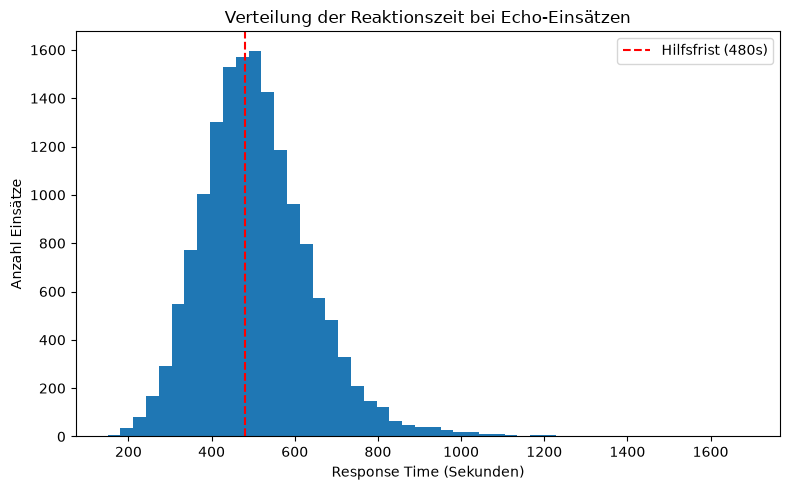

In [37]:
echo_response = df_mission_data.loc[df_mission_data["criticality_E"], "response_time"]

print(echo_response.describe())
print()
print("Median Überschreitung (nur verfehlte Fälle):", (echo_response[echo_response > 480] - 480).median(), "Sekunden")
print("Mittlere Überschreitung (nur verfehlte Fälle):", (echo_response[echo_response > 480] - 480).mean(), "Sekunden")

plt.figure(figsize=(8, 5))
plt.hist(echo_response, bins=50)
plt.axvline(480, color="red", linestyle="--", label="Hilfsfrist (480s)")
plt.xlabel("Response Time (Sekunden)")
plt.ylabel("Anzahl Einsätze")
plt.title("Verteilung der Reaktionszeit bei Echo-Einsätzen")
plt.legend()
plt.tight_layout()
plt.show()

# Zielvariable & Features finalisieren

Feature-Matrix nur aus den Variablen mit belegtem Effekt: Kritikalität (AMPDS) und Bezirk, plus Einsatztyp (Rettungsdienst vs. Mischtyp). Wochentag, Monat, Wetter und Leitstelle bewusst ausgeschlossen (siehe Begründungen oben).

In [23]:
# Feature-Matrix X zusammenstellen (nur Dringlichkeit, Bezirk, Einsatztyp)
feature_spalten = (
    [c for c in df_mission_data.columns if c.startswith("criticality_")] +
    [c for c in df_mission_data.columns if c.startswith("district_")] +
    ["typ_Rettungsdienst", "typ_Rettungsdienst mit Technischer Hilfeleistung"]
)

X = df_mission_data[feature_spalten]
y = df_mission_data["hilfsfrist"]

print(X.shape, y.shape)
print(X.columns.tolist())

(1714419, 21) (1714419,)
['criticality_A', 'criticality_B', 'criticality_C', 'criticality_D', 'criticality_E', 'criticality_O', 'criticality_unbekannt', 'district_Charlottenburg-Wilmersdorf', 'district_Friedrichshain-Kreuzberg', 'district_Lichtenberg', 'district_Marzahn-Hellersdorf', 'district_Mitte', 'district_Neukölln', 'district_Pankow', 'district_Reinickendorf', 'district_Spandau', 'district_Steglitz-Zehlendorf', 'district_Tempelhof-Schöneberg', 'district_Treptow-Köpenick', 'typ_Rettungsdienst', 'typ_Rettungsdienst mit Technischer Hilfeleistung']


# Modelltraining

## Modell 1: Logistische Regression

Nachdem die Feature-Matrix steht, trainieren wir zunächst ein einfaches, gut nachvollziehbares Modell: die Logistische Regression. Sie sagt vorher, ob die Hilfsfrist eingehalten wird (Ja/Nein), basierend auf Kritikalität, Bezirk und Einsatztyp. Sie dient als **Ausgangspunkt (Baseline)** — bevor wir komplexere Modelle ausprobieren, wollen wir wissen, wie gut schon ein einfaches Modell abschneidet.

### Variante A: ohne `class_weight` (Baseline)

Ein wichtiges Problem in unseren Daten: nur etwa 19,7% der Einsätze halten die Hilfsfrist ein, der Rest (80,3%) nicht — die Klassen sind also **unausgeglichen**. Ein Modell könnte deshalb einfach immer "Hilfsfrist nicht eingehalten" vorhersagen und hätte damit schon ca. 80% Trefferquote (Accuracy), ohne wirklich etwas gelernt zu haben. Diese erste Variante zeigt genau dieses Problem.

In [24]:
# Train/Test Split (80/20)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Anteil hilfsfrist=True (train):", y_train.mean())
print("Anteil hilfsfrist=True (test):", y_test.mean())

# Logistische Regression trainieren
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

print("Trainings-Accuracy:", log_reg.score(X_train, y_train))
print("Test-Accuracy:", log_reg.score(X_test, y_test))

y_pred = log_reg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Train: (1371535, 21) (1371535,)
Test: (342884, 21) (342884,)
Anteil hilfsfrist=True (train): 0.1985687569037611
Anteil hilfsfrist=True (test): 0.19856861212538351
Trainings-Accuracy: 0.8020531739984762
Test-Accuracy: 0.8021284166073658
[[274194    604]
 [ 67243    843]]
              precision    recall  f1-score   support

       False       0.80      1.00      0.89    274798
        True       0.58      0.01      0.02     68086

    accuracy                           0.80    342884
   macro avg       0.69      0.51      0.46    342884
weighted avg       0.76      0.80      0.72    342884



### Variante B: mit `class_weight="balanced"`

Um das Ungleichgewicht auszugleichen, gewichtet diese Variante die seltenere Klasse ("Hilfsfrist eingehalten") stärker, damit das Modell nicht mehr einfach die Mehrheitsklasse rät. Erwartung: die Gesamt-Trefferquote (Accuracy) sinkt vermutlich, dafür sollte das Modell die seltene Klasse besser erkennen (höherer Recall).

In [25]:
# Logistische Regression mit class_weight="balanced" (Vergleich zur unbalanced Version oben)
log_reg_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg_balanced.fit(X_train, y_train)

print("Trainings-Accuracy:", log_reg_balanced.score(X_train, y_train))
print("Test-Accuracy:", log_reg_balanced.score(X_test, y_test))

y_pred_balanced = log_reg_balanced.predict(X_test)
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Trainings-Accuracy: 0.5781937755872071
Test-Accuracy: 0.5773585235823194
[[156205 118593]
 [ 26324  41762]]
              precision    recall  f1-score   support

       False       0.86      0.57      0.68    274798
        True       0.26      0.61      0.37     68086

    accuracy                           0.58    342884
   macro avg       0.56      0.59      0.52    342884
weighted avg       0.74      0.58      0.62    342884



## Modell 2: Random Forest

Als zweites Modell probieren wir einen Random Forest aus. Er kann im Gegensatz zur Logistischen Regression auch **nichtlineare Zusammenhänge und Wechselwirkungen** abbilden — z.B. dass eine bestimmte Kritikalität in einem bestimmten Bezirk besonders problematisch ist. Wir vergleichen, ob das die Vorhersage gegenüber der Logistischen Regression verbessert.

In [26]:
# Random Forest trainieren
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Trainings-Accuracy:", rf.score(X_train, y_train))
print("Test-Accuracy:", rf.score(X_test, y_test))

y_pred_rf = rf.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Trainings-Accuracy: 0.6170925277152971
Test-Accuracy: 0.6152372230841917
[[173419 101379]
 [ 30550  37536]]
              precision    recall  f1-score   support

       False       0.85      0.63      0.72    274798
        True       0.27      0.55      0.36     68086

    accuracy                           0.62    342884
   macro avg       0.56      0.59      0.54    342884
weighted avg       0.74      0.62      0.65    342884



## Modell 3: Random Forest Regression

In [27]:
# Regressionsmodell: response_time (Sekunden) statt hilfsfrist (Ja/Nein) vorhersagen
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

y_minuten = df_mission_data["response_time"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_minuten, test_size=0.2, random_state=42
)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)

y_pred_r = rf_reg.predict(X_test_r)
print("Mittlerer absoluter Fehler (Sekunden):", mean_absolute_error(y_test_r, y_pred_r))
print("Mittlerer absoluter Fehler (Minuten):", mean_absolute_error(y_test_r, y_pred_r) / 60)

Mittlerer absoluter Fehler (Sekunden): 174.27304491148422
Mittlerer absoluter Fehler (Minuten): 2.904550748524737


# Modellbewertung

## Vergleich Log. Regression vs. Random Forest

Jetzt stellen wir alle drei bisher trainierten Klassifikationsmodelle (LogReg unbalanced, LogReg balanced, Random Forest) anhand der gleichen Kennzahlen nebeneinander, um zu sehen, welches am besten mit dem Klassenungleichgewicht umgeht und die Hilfsfrist-Einhaltung am zuverlässigsten vorhersagt.

In [28]:
# Accuracy, F1, Precision, Recall im direkten Vergleich
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

modelle = {
    "LogReg (unbalanced)": y_pred,
    "LogReg (balanced)": y_pred_balanced,
    "Random Forest": y_pred_rf,
}

vergleich = []
for name, pred in modelle.items():
    vergleich.append({
        "Modell": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (True)": precision_score(y_test, pred),
        "Recall (True)": recall_score(y_test, pred),
        "F1 (True)": f1_score(y_test, pred),
    })

df_vergleich = pd.DataFrame(vergleich).set_index("Modell")
print(df_vergleich)

                     Accuracy  Precision (True)  Recall (True)  F1 (True)
Modell                                                                   
LogReg (unbalanced)  0.802128          0.582585       0.012381   0.024247
LogReg (balanced)    0.577359          0.260435       0.613371   0.365626
Random Forest        0.615237          0.270208       0.551303   0.362665


## Random Forest: Feature Importances

Welche der drei Eingangsgrößen (Kritikalität, Bezirk, Einsatztyp) nutzt der Random Forest am meisten für seine Vorhersage? Das ist ein direkter Test unserer ersten Hypothese (Einsatzart/Kritikalität beeinflusst die Hilfsfrist) und liefert zusätzlich Hinweise darauf, wie stark der Bezirk im Vergleich dazu ins Gewicht fällt.

criticality_D                                       0.165189
district_Friedrichshain-Kreuzberg                   0.154890
district_Mitte                                      0.096858
criticality_E                                       0.072315
district_Treptow-Köpenick                           0.063648
district_Marzahn-Hellersdorf                        0.061720
criticality_A                                       0.046077
district_Charlottenburg-Wilmersdorf                 0.045229
typ_Rettungsdienst                                  0.041216
criticality_unbekannt                               0.040583
typ_Rettungsdienst mit Technischer Hilfeleistung    0.039512
criticality_B                                       0.036385
criticality_C                                       0.030327
district_Lichtenberg                                0.025666
district_Tempelhof-Schöneberg                       0.023213
district_Pankow                                     0.012367
district_Steglitz-Zehlen

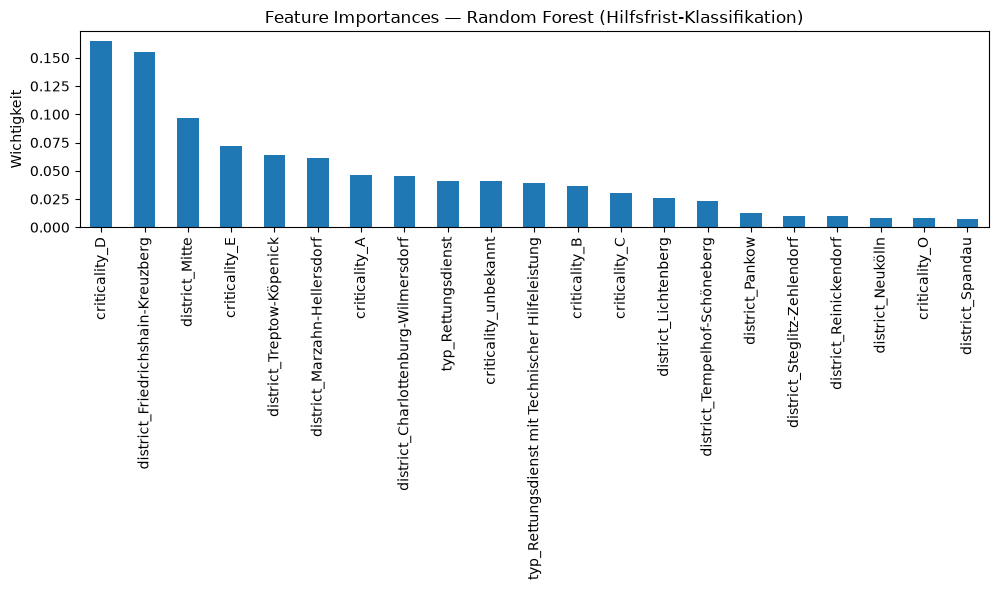

In [29]:
# Welche Features nutzt der Random Forest (Klassifikation) am meisten?
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar")
plt.ylabel("Wichtigkeit")
plt.title("Feature Importances — Random Forest (Hilfsfrist-Klassifikation)")
plt.tight_layout()
plt.show()

# Interpretation

**Welche Prädiktorgruppe erklärt am meisten?**

Modellvergleich (Test-Set):

| Modell | Accuracy | Precision (True) | Recall (True) | F1 (True) |
|---|---|---|---|---|
| LogReg (unbalanced) | 0,80 | 0,58 | **0,01** | 0,02 |
| LogReg (balanced) | 0,58 | 0,26 | 0,61 | **0,37** |
| Random Forest | 0,62 | 0,27 | 0,55 | 0,36 |

Random Forest und balancierte LogReg liegen mit F1≈0,36–0,37 etwa gleichauf — die unbalancierte LogReg ist mit Recall=0,01 wertlos für die eigentliche Fragestellung (erkennt fast keine eingehaltenen Hilfsfristen).

**Feature Importances (Random Forest):** die größten Gewichte liegen auf `criticality_D` (16,5%), `district_Friedrichshain-Kreuzberg` (15,5%), `district_Mitte` (9,7%) und `criticality_E` (7,2%) — Kritikalität und Bezirk dominieren beide, in etwa vergleichbarer Größenordnung. Das bestätigt quantitativ, was die EDA schon zeigte:

1. **Kritikalität (AMPDS)** — stärkster Einzeleffekt in der EDA (Quote steigt von 9,7% bei O auf 44,8% bei E).
2. **Bezirk** — fast ebenso wichtig im Modell, Spannweite 12,6–30,5% in der EDA.
3. **Bezirk × Kritikalität** — additiv, kein Bezirk durchbricht das Kritikalitätsmuster; bei Echo-Fällen ist die Bezirks-Lücke mit 40 Punkten am größten.
4. **Leitstelle** — real (p≈0), aber moderat (~9% erklärte Varianz) und methodisch unsicher; bewusst nicht ins Modell aufgenommen.
5. **Wochentag** — schwacher Nebeneffekt. **Wetter, Monat** — kein nachweisbarer Effekt.

**Wo versagt das Modell?**

- Mit nur drei groben Kategorien bleibt viel Restvarianz unerklärt (Verkehr, Tageszeit, Fahrzeugverfügbarkeit — nicht in den Daten enthalten).
- Klassenungleichgewicht (80/20) lässt die unbalancierte LogReg in die Falle laufen: hohe Accuracy täuscht, sie sagt fast immer "False" vorher.
- Mit Gewichtung wird die Vorhersage ehrlicher, aber F1≈0,36–0,37 bleibt weit von einem verlässlichen Einzelfall-Modell entfernt.
- Das Regressionsmodell (response_time direkt) hat einen mittleren Fehler von ~2,9 Minuten — brauchbar als grobe Schätzung pro Kategorie-Kombination, nicht für präzise Einzelfall-Aussagen.

# Reflexion & KV-Ausblick

**Grenzen der Analyse:**
- 8-Minuten-Schwelle ist medizinisch begründet, aber nicht Berlins offizielles Schutzziel (10/11 Min., 90%) — Zahlen nicht 1:1 mit offiziellen Statistiken vergleichbar.
- Leitstellen-Variablen methodisch unklar (Mehrfachanrufe pro Vorfall nicht ausschließbar) — deshalb nicht im Modell, echter Effekt evtl. unterschätzt.
- Nur 12 Bezirke als Geo-Auflösung; Planungsraum-Ebene zeigt deutlich größere Spannweite (72,7 Punkte) — räumliche Varianz im Modell wahrscheinlich unterschätzt.
- Kreislaufstillstand-Kategorie enthält vermutlich auch bereits verstorbene Personen — 55%-Verfehlungsquote bei Echo nicht 1:1 als "vermeidbare Todesfälle" interpretierbar.
- Datenzeiträume uneinheitlich: Mission/Wetter 2022–2025, Leitstelle nur 2024–2025 — keine vollständig deckungsgleiche Basis für alle drei Hypothesen.
- Nur Korrelationen geprüft, keine Kausalität (Sturmtage als einziges halbwegs kausales Beispiel).
- Einfache Modelle (3 Kategorien, keine Interaktionsterme); kein Gradient Boosting, keine Mehrebenen-Modelle getestet.
- Keine Uhrzeit-Variable möglich (Datenquelle liefert nur Tagesdatum) — Tageszeit-Effekte komplett unbeobachtbar.

**KV-Ausblick (offene Folgefrage):**
- Die Berliner Feuerwehr kann Einsätze, die laut Meldebild nicht zwingend den Rettungsdienst brauchen, an die Kassenärztliche Vereinigung (KV) Berlin abgeben — ein zusätzlicher, in dieser Analyse nicht ausgewerteter Datensatz (`daily_kv_data.csv`) existiert dafür.
- Ob und wie stark diese Abgabe die Leitstellen-Auslastung und damit die Hilfsfrist tatsächlich entlastet, ist mit den hier verwendeten Daten/Methoden nicht abschließend zu beantworten — dafür bräuchte es eine eigene, zeitlich differenziertere Untersuchung (z.B. wirkt eine Abgabe am Vormittag auf die Hilfsfrist am Nachmittag?).
- Bleibt als offene Frage für eine mögliche KV-Kooperation/Folgeanalyse stehen, statt hier eine unbelegte Wirkung zu behaupten.

# KI Nutzung im Notebook

Für den Datenanalyse und Modelltrainingsteil wurde so wenig wie möglich auf KI zurückgegriffen. Wir haben uns mithilfe der Vorlesungsfolien und Recherchen im Internet am Thema langgehangelt.  

Zudem der Coding Agent kam vermehrt zum Einsatz bei Debugging Fragen, sowie der Korrektur der Texte. Vor allem die visuell ansprechendere Gestaltung der Texte wurde mit Hilfe von KI umgesetzt.  

Vor allem die spätere Visualisierung über eine Webapp barg einige Herausforderungen. Dennoch waren viele vorhaben gut dokumentiert, sodass wir auch hier durch klassische Recherchen weit gekommen sind.  

# Quellen

https://rettungslandschaft.steiger-stiftung.de/notrufbearbeitung-und-hilfsfrist/  

https://www.elab2go.de/demo-py/

https://open-meteo.com/en/docs/historical-forecast-api?start_date=2022-01-01&end_date=2025-12-31&timezone=Europe%2FBerlin&hourly=&daily=temperature_2m_max,weather_code,precipitation_sum,snowfall_sum,wind_speed_10m_max#hourly_weather_variables

https://github.com/Berliner-Feuerwehr/BF-Open-Data

https://rettungslandschaft.steiger-stiftung.de/hilfsfristzeiten-definitionen/

https://www.berliner-feuerwehr.de/service/open-data/

https://www.berliner-feuerwehr.de/fileadmin/bfw/dokumente/status-5/G668_Orga-RD_Berlin__Stand_22.07.16_.pdf

# Vorbereitung für die Visualisierung
## Ab hier haben wir das Notebook mit Vibecoding per Coding Agent (Claude) gestaltet. Dabei haben wir uns **nicht** auf die Ausgaben verlassen sondern uns explizit Vorschläge geben lassen wir unsere Visualisierungsvorstellung umgesetzt werden kann. Die Codezeilen wurden geprüft und kritisch bewertet.

### Die Erkenntnisse wurden verarbeitet, sodass eine Laienfreundliche Visualisierung möglich ist.

### Robustheitscheck: `dispatchcode_category` statt `criticality`

Für die geplante interaktive App (Bezirk + konkretes Krankheitsbild statt AMPDS-Buchstabe) prüfen wir, ob die feinere `dispatchcode_category` (z.B. "Kreislaufstillstand", "Sturz") die Modellgüte gegenüber der gröberen `criticality`-Stufe wesentlich verändert. Gleicher Bezirk/Einsatztyp, gleicher Split (gleicher `random_state`, gleiches `y_minuten`) — nur das Dringlichkeits-Feature wird ausgetauscht.

In [30]:
# dispatchcode_category encodieren (bisher rohe String-Spalte, noch nicht one-hot)
df_mission_data["dispatchcode_category"] = df_mission_data["dispatchcode_category"].fillna("unbekannt")
df_mission_data = pd.get_dummies(df_mission_data, columns=["dispatchcode_category"], prefix="kategorie")

# Feature-Matrix mit Kategorie statt Kritikalität (Bezirk/Einsatztyp identisch zu X)
feature_spalten_kategorie = (
        [c for c in df_mission_data.columns if c.startswith("kategorie_")] +
        [c for c in df_mission_data.columns if c.startswith("district_")] +
        ["typ_Rettungsdienst", "typ_Rettungsdienst mit Technischer Hilfeleistung"]
)
X_kategorie = df_mission_data[feature_spalten_kategorie]

# Gleicher Split (gleicher random_state, gleiches y_minuten) wie beim Kritikalitäts-Modell oben
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_kategorie, y_minuten, test_size=0.2, random_state=42
)

rf_reg_kategorie = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_kategorie.fit(X_train_k, y_train_k)

y_pred_k = rf_reg_kategorie.predict(X_test_k)
mae_kategorie = mean_absolute_error(y_test_k, y_pred_k)

print("MAE mit criticality (Minuten):", mean_absolute_error(y_test_r, y_pred_r) / 60)
print("MAE mit dispatchcode_category (Minuten):", mae_kategorie / 60)

MAE mit criticality (Minuten): 2.904550748524737
MAE mit dispatchcode_category (Minuten): 2.9147431723201422


In [31]:
# Kategorie-Code in Klartext umwandeln
df_codes = pd.read_excel("data/BF-Open-Data/Datasets/Dispatchcodes/Mediznische Codezuordnung Berliner Feuerwehr_20260521.xlsx", sheet_name="AMPDS-Codes")
df_codes["kategorie_code"] = df_codes["Code"].str[:2]
kategorie_labels = df_codes[["kategorie_code", "Hauptbeschwerde_Text_Original"]].drop_duplicates()
print(df_codes.groupby("kategorie_code")["Hauptbeschwerde_Text_Original"].nunique().value_counts())
print(kategorie_labels.shape)

Hauptbeschwerde_Text_Original
1    35
Name: count, dtype: int64
(35, 2)


In [32]:
kategorie_spalten = [c for c in df_mission_data.columns if c.startswith("kategorie_")]
district_spalten = [c for c in df_mission_data.columns if c.startswith("district_")]

zeilen = []
for d_col in district_spalten:
    bezirk = d_col.replace("district_", "")
    for k_col in kategorie_spalten:
        kategorie_raw = k_col.replace("kategorie_", "")
        maske = df_mission_data[d_col] & df_mission_data[k_col]
        zeilen.append({
            "bezirk": bezirk,
            "kategorie_raw": kategorie_raw,
            "n": maske.sum(),
            "median_response_time": df_mission_data.loc[maske, "response_time"].median(),
            "hilfsfrist_quote": df_mission_data.loc[maske, "hilfsfrist"].mean(),
        })

df_stats = pd.DataFrame(zeilen)

# n>=30 Schwelle (statistische Verlässlichkeit pro Bezirk x Kategorie)
df_stats = df_stats[df_stats["n"] >= 30]

# kategorie_raw ist "1.0", "10.0", ... oder "unbekannt" -> auf 2-stelligen Code formatieren
df_stats["kategorie_code"] = pd.to_numeric(df_stats["kategorie_raw"], errors="coerce")
df_stats = df_stats.dropna(subset=["kategorie_code"])  # wirft "unbekannt" raus
df_stats["kategorie_code"] = df_stats["kategorie_code"].astype(int).astype(str).str.zfill(2)

# Mit Labels mergen (inner join wirft automatisch die nicht gemappten Codes 35/37/52-90 raus)
df_stats = df_stats.merge(kategorie_labels, on="kategorie_code", how="inner")

print(df_stats.shape)
df_stats.head()

(371, 7)


,bezirk,kategorie_raw,n,median_response_time,hilfsfrist_quote,kategorie_code,Hauptbeschwerde_Text_Original
0,Charlottenburg-Wilmersdorf,1.0,7402,647.0,0.178195,01,"Bauchschmerzen, -beschwerden"
1,Charlottenburg-Wilmersdorf,2.0,1319,588.0,0.263836,02,Allergie (Überreaktion) / Kontakt mit giftigen...
2,Charlottenburg-Wilmersdorf,3.0,128,671.5,0.132812,03,Tierbiss / Tierangriff
3,Charlottenburg-Wilmersdorf,4.0,2913,608.0,0.224511,04,Körperverletzung / Sexualdelikt / Elektroschocker
4,Charlottenburg-Wilmersdorf,5.0,2546,670.5,0.157502,05,Rückenschmerzen (Nicht traumatische Rückenschm...


In [33]:
import os
os.makedirs("app/data", exist_ok=True)
df_stats.to_csv("app/data/bezirk_kategorie_hilfsfrist.csv", index=False)

In [34]:
import joblib
joblib.dump(rf_reg_kategorie, "app/data/rf_reg_kategorie.pkl")
joblib.dump(feature_spalten_kategorie, "app/data/feature_spalten_kategorie.pkl")


['app/data/feature_spalten_kategorie.pkl']

In [35]:
criticality_spalten = [c for c in df_mission_data.columns if c.startswith("criticality_")]

zeilen_krit = []
for d_col in district_spalten:
    bezirk = d_col.replace("district_", "")
    for k_col in kategorie_spalten:
        kategorie_raw = k_col.replace("kategorie_", "")
        for c_col in criticality_spalten:
            crit = c_col.replace("criticality_", "")
            maske = df_mission_data[d_col] & df_mission_data[k_col] & df_mission_data[c_col]
            n = maske.sum()
            if n == 0:
                continue
            zeilen_krit.append({
                "bezirk": bezirk,
                "kategorie_raw": kategorie_raw,
                "criticality": crit,
                "n": n,
                "hilfsfrist_quote": df_mission_data.loc[maske, "hilfsfrist"].mean(),
            })

df_krit = pd.DataFrame(zeilen_krit)
df_krit = df_krit[df_krit["n"] >= 30]

# Kategorie-Code formatieren und mit Labels mergen (wie bei df_stats)
df_krit["kategorie_code"] = pd.to_numeric(df_krit["kategorie_raw"], errors="coerce")
df_krit = df_krit.dropna(subset=["kategorie_code"])
df_krit["kategorie_code"] = df_krit["kategorie_code"].astype(int).astype(str).str.zfill(2)
df_krit = df_krit.merge(kategorie_labels, on="kategorie_code", how="inner")

print(df_krit.shape)
df_krit.head()

(1018, 7)


,bezirk,kategorie_raw,criticality,n,hilfsfrist_quote,kategorie_code,Hauptbeschwerde_Text_Original
0,Charlottenburg-Wilmersdorf,1.0,A,1230,0.097561,01,"Bauchschmerzen, -beschwerden"
1,Charlottenburg-Wilmersdorf,1.0,C,5271,0.191045,01,"Bauchschmerzen, -beschwerden"
2,Charlottenburg-Wilmersdorf,1.0,D,901,0.213097,01,"Bauchschmerzen, -beschwerden"
3,Charlottenburg-Wilmersdorf,2.0,A,90,0.133333,02,Allergie (Überreaktion) / Kontakt mit giftigen...
4,Charlottenburg-Wilmersdorf,2.0,B,271,0.147601,02,Allergie (Überreaktion) / Kontakt mit giftigen...


In [36]:
df_krit.to_csv("app/data/bezirk_kategorie_kritikalitaet.csv", index=False)
